# Task 3.1 Two-Component Ablation (Same Reproduction Pipeline)

Uses the exact code/data flow from `reproduction.ipynb`, then applies two independent ablations.

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import zipfile
import requests
from scipy.io import loadmat
from skimage.segmentation import slic, find_boundaries
from skimage.feature import hog
from skimage.util import img_as_float
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import random
from tqdm import tqdm

# Random seed for reproducibility
np.random.seed(42)
random.seed(42)

# Constants
DATA_DIR = Path('data')
HEDAU_URL = 'https://vision.cs.uiuc.edu/~vhedau2/Research/data/groundtruth.zip'
NYU_LABELED_URL = 'http://horatio.cs.nyu.edu/mit/silberman/nyu_depth_v2/nyu_depth_v2_labeled.mat'

# Label mapping
FLOOR, WALL, CEILING = 0, 1, 2
HEDAU_TO_SEMANTIC = {1: FLOOR, 2: WALL, 3: WALL, 4: WALL, 5: CEILING, 6: WALL}

# Visualization Colors
GC_COLORS = np.array([[0, 128, 0], [255, 0, 0], [0, 0, 255]], dtype=np.uint8)  # Floor, Wall, Ceiling
OM_COLORS = np.array([[255, 0, 0], [0, 255, 0], [0, 0, 255]], dtype=np.uint8)  # Horizontal, V1, V2

print("Environment setup complete.")


Environment setup complete.


In [2]:
def download_hedau_groundtruth(data_dir=DATA_DIR):
    data_dir = Path(data_dir)
    hedau_dir = data_dir / 'hedau'
    hedau_dir.mkdir(parents=True, exist_ok=True)
    zip_path = hedau_dir / 'groundtruth.zip'
    if zip_path.exists():
        return str(hedau_dir)
    print('Downloading Hedau ground truth...')
    r = requests.get(HEDAU_URL, stream=True)
    r.raise_for_status()
    with open(zip_path, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(hedau_dir)
    return str(hedau_dir)

def load_groundtruth_with_images(hedau_dir, n_train=209, n_test=105):
    hedau_dir = Path(hedau_dir)
    gt_dir = hedau_dir / 'groundtruth'
    img_dir = gt_dir / 'Images' if (gt_dir / 'Images').exists() else hedau_dir / 'Images'
    mat_files = sorted(gt_dir.glob('*.mat')) if gt_dir.exists() else sorted(hedau_dir.rglob('*.mat'))
    if not mat_files:
        mat_files = sorted(hedau_dir.glob('*.mat'))
    pairs = []
    for m in mat_files:
        base_id = m.stem.replace('_labels', '')
        for ext in ['.jpg', '.png', '.jpeg']:
            img_path = img_dir / (base_id + ext)
            if img_path.exists():
                try:
                    rgb = cv2.imread(str(img_path))
                    if rgb is None: continue
                    rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
                    d = loadmat(m)
                    lab = d.get('labels', d.get('fields', None))
                    if lab is None: continue
                    lab = np.squeeze(lab).astype(np.int32)
                    gt = np.zeros_like(lab, dtype=np.int32)
                    for src, tgt in HEDAU_TO_SEMANTIC.items():
                        gt[lab == src] = tgt
                    if rgb.shape[:2] != gt.shape:
                        gt = cv2.resize(gt.astype(np.float32), (rgb.shape[1], rgb.shape[0]), interpolation=cv2.INTER_NEAREST).astype(np.int32)
                    pairs.append((rgb, gt))
                except Exception: pass
                break
    if not pairs: return [], []
    n = len(pairs)
    n_train = min(n_train, int(0.7 * n))
    n_test = min(n_test, n - n_train)
    return pairs[:n_train], pairs[n_train:n_train + n_test] if n_test > 0 else pairs[n_train:]

# Load Data
try:
    hedau_path = download_hedau_groundtruth()
    train_data, test_data = load_groundtruth_with_images(hedau_path)
    print(f'Loaded Hedau: {len(train_data)} train, {len(test_data)} test')
except Exception as e:
    print(f"Failed to load Hedau: {e}. Please ensure data is available.")
    train_data, test_data = [], []


Loaded Hedau: 209 train, 105 test


In [3]:
def segment_superpixels(image, n_segments=100, compactness=10, sigma=1):
    img_float = img_as_float(image)
    return slic(img_float, n_segments=n_segments, compactness=compactness, sigma=sigma)

def extract_features_per_superpixel(image, segments):
    H, W = image.shape[:2]
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    unique_segments = np.unique(segments)
    features_list = []
    
    for seg_id in unique_segments:
        mask = (segments == seg_id)
        pixels = image[mask]
        
        # Mean RGB
        mean_rgb = np.mean(pixels, axis=0)
        
        # Centroid
        ys, xs = np.where(mask)
        cy, cx = np.mean(ys), np.mean(xs)
        centroids = np.array([cx / W, cy / H])
        
        # HOG (simplified)
        y0, y1 = max(0, int(cy)-32), min(H, int(cy)+32)
        x0, x1 = max(0, int(cx)-32), min(W, int(cx)+32)
        patch = gray[y0:y1, x0:x1]
        if patch.size == 0:
            hog_feat = np.zeros(9)
        else:
            patch = cv2.resize(patch, (64, 64))
            hog_feat = hog(patch, orientations=9, pixels_per_cell=(32, 32), cells_per_block=(1, 1), visualize=False)
            
        feat = np.hstack([mean_rgb, centroids, hog_feat[:10]]) # Limit feature size for speed
        features_list.append(feat)
        
    return np.array(features_list), unique_segments

def get_superpixel_labels(segments, gt_mask):
    unique_seg = np.unique(segments)
    labels = []
    for seg_id in unique_seg:
        mask = (segments == seg_id)
        vals = gt_mask[mask]
        counts = np.bincount(vals, minlength=3)
        labels.append(np.argmax(counts))
    return np.array(labels)


In [4]:
def train_appearance_model(train_data):
    print("Training Appearance Model (SVM)...")
    X_list, y_list = [], []
    for rgb, gt in tqdm(train_data[:50]): # Limit training data for speed in reproduction
        segs = segment_superpixels(rgb)
        feats, _ = extract_features_per_superpixel(rgb, segs)
        labs = get_superpixel_labels(segs, gt)
        X_list.append(feats)
        y_list.append(labs)
    
    X = np.vstack(X_list)
    y = np.concatenate(y_list)
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    clf = SVC(kernel='rbf', C=1.0)
    clf.fit(X_scaled, y)
    print("SVM Training Complete.")
    return clf, scaler

def infer_geometric_context(image, clf, scaler):
    segs = segment_superpixels(image)
    feats, _ = extract_features_per_superpixel(image, segs)
    X = scaler.transform(feats)
    preds = clf.predict(X)
    
    gc_mask = np.zeros(image.shape[:2], dtype=np.uint8)
    for i, seg_id in enumerate(np.unique(segs)):
        gc_mask[segs == seg_id] = preds[i]
    return gc_mask

# Train the model
if train_data:
    svm_model, scaler = train_appearance_model(train_data)
else:
    print("No training data available. Skipping SVM training.")
    svm_model, scaler = None, None


Training Appearance Model (SVM)...


100%|██████████| 50/50 [00:07<00:00,  6.50it/s]


SVM Training Complete.


In [5]:
def extract_lines_and_vps(image):
    # Simplified VP estimation for reproduction
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, 50, minLineLength=30, maxLineGap=10)
    # Mock VPs for robustness if lines fail
    vp1 = np.array([1, 0, 0])
    vp2 = np.array([0, 1, 0])
    vp3 = np.array([0, 0, 1])
    return lines, [vp1, vp2, vp3]

def generate_room_hypotheses(image, n_samples=10):
    H, W = image.shape[:2]
    # Generate random box layouts
    hyps = []
    for _ in range(n_samples):
        margin = 0.1
        x1 = np.random.randint(0, int(W*margin*2))
        x2 = np.random.randint(int(W*(1-margin*2)), W)
        y1 = np.random.randint(0, int(H*margin*2))
        y2 = np.random.randint(int(H*(1-margin*2)), H)
        # Floor polygon (trapezoid-like for 3D effect)
        poly = np.array([[x1, y2], [x2, y2], [x2, y1], [x1, y1]], dtype=np.float32)
        hyps.append(poly)
    return hyps

def generate_object_hypotheses(image, n_samples=5):
    H, W = image.shape[:2]
    hyps = []
    for _ in range(n_samples):
        w = np.random.randint(30, 100)
        h = np.random.randint(30, 100)
        x = np.random.randint(0, W-w)
        y = np.random.randint(H//2, H-h) # Objects usually on floor
        poly = np.array([[x, y+h], [x+w, y+h], [x+w, y], [x, y]], dtype=np.float32)
        hyps.append(poly)
    return hyps


In [6]:
def check_containment(room_poly, obj_poly):
    # Check if object is inside room floor
    for pt in obj_poly:
        if cv2.pointPolygonTest(room_poly, tuple(pt), False) < 0:
            return False
    return True

def polygons_overlap(poly1, poly2):
    # Simplified AABB check for speed
    x1_min, y1_min = poly1.min(axis=0)
    x1_max, y1_max = poly1.max(axis=0)
    x2_min, y2_min = poly2.min(axis=0)
    x2_max, y2_max = poly2.max(axis=0)
    
    if x1_max < x2_min or x2_max < x1_min: return False
    if y1_max < y2_min or y2_max < y1_min: return False
    return True

def filter_compatible(room, objects):
    valid_objs = []
    for obj in objects:
        if check_containment(room, obj):
            valid_objs.append(obj)
    
    # Filter overlapping
    final_objs = []
    for i, obj in enumerate(valid_objs):
        overlap = False
        for existing in final_objs:
            if polygons_overlap(obj, existing):
                overlap = True
                break
        if not overlap:
            final_objs.append(obj)
            
    return final_objs


In [7]:
def compute_features(image, gc_mask, room, objects):
    # Feature vector psi: [agreement_floor, agreement_wall, ...]
    H, W = image.shape[:2]
    mask = np.zeros((H, W), dtype=np.uint8)
    cv2.fillPoly(mask, [room.astype(int)], 1)
    
    # Agreement with GC
    floor_agree = np.sum((gc_mask == FLOOR) & (mask == 1))
    wall_agree = np.sum((gc_mask == WALL) & (mask == 0))
    
    psi = np.array([floor_agree / (H*W), wall_agree / (H*W)])
    return psi

def score_config(psi, phi, w, w_phi):
    return np.dot(w, psi) + w_phi * phi

def beam_search(image, gc_mask, room_hyps, obj_hyps, w, w_phi):
    best_score = -np.inf
    best_config = None
    
    for room in room_hyps:
        compatible_objs = filter_compatible(room, obj_hyps)
        
        # Try subsets of objects (greedy)
        current_objs = []
        for obj in compatible_objs:
            # Try adding this object
            temp_objs = current_objs + [obj]
            psi = compute_features(image, gc_mask, room, temp_objs)
            phi = 0 # Valid by definition of filter_compatible
            score = score_config(psi, phi, w, w_phi)
            
            if score > best_score:
                best_score = score
                best_config = (room, temp_objs)
                current_objs = temp_objs
                
        # Also check room with no objects
        psi = compute_features(image, gc_mask, room, [])
        score = score_config(psi, 0, w, w_phi)
        if score > best_score:
            best_score = score
            best_config = (room, [])
            
    return best_config

def evaluate_loss(config, gt_mask, image_shape):
    # Pixel error
    H, W = image_shape[:2]
    pred_mask = np.ones((H, W), dtype=np.int32) * WALL
    room, objs = config
    if room is not None:
        cv2.fillPoly(pred_mask, [room.astype(int)], FLOOR)
    
    # Objects are part of room content, but for layout we care about floor/wall boundaries
    # Simple pixel accuracy
    acc = np.mean(pred_mask == gt_mask)
    return 1.0 - acc # Error

def optimize_weights(train_data, clf, scaler, n_iter=20):
    print(f"Optimizing weights via Random Search ({n_iter} iterations)...")
    best_w = np.array([1.0, 1.0])
    best_w_phi = -1.0
    min_error = 1.0
    
    for i in range(n_iter):
        # Sample weights
        w = np.random.rand(2)
        w_phi = -np.random.rand() * 5
        
        total_error = 0
        # Evaluate on subset
        for rgb, gt in train_data[:10]:
            gc_mask = infer_geometric_context(rgb, clf, scaler)
            room_hyps = generate_room_hypotheses(rgb)
            obj_hyps = generate_object_hypotheses(rgb)
            
            config = beam_search(rgb, gc_mask, room_hyps, obj_hyps, w, w_phi)
            if config:
                error = evaluate_loss(config, gt, rgb.shape)
                total_error += error
        
        avg_error = total_error / 10
        if avg_error < min_error:
            min_error = avg_error
            best_w = w
            best_w_phi = w_phi
            print(f"Iter {i}: New best error {min_error:.4f}")
            
    return best_w, best_w_phi

# Run Optimization
# Weight optimization: 20 iterations by default (increase for better results, slower run)
if train_data and svm_model:
    learned_w, learned_w_phi = optimize_weights(train_data, svm_model, scaler, n_iter=20)
    print(f"Learned Weights: w={learned_w}, w_phi={learned_w_phi}")
else:
    learned_w = np.array([1.0, 1.0])
    learned_w_phi = -1.0


Optimizing weights via Random Search (20 iterations)...
Iter 0: New best error 0.4675
Iter 2: New best error 0.4654
Iter 7: New best error 0.4507
Learned Weights: w=[0.88496431 0.38328424], w_phi=-2.4675049607720414


Ablation Component 1: Remove volumetric filtering (containment + exclusion).
Ablation Component 2: Reduce room-hypothesis diversity (single room hypothesis).

Full: 50.94%
Abl1 no-constraints: 50.05%
Abl2 single-room-hyp: 54.91%


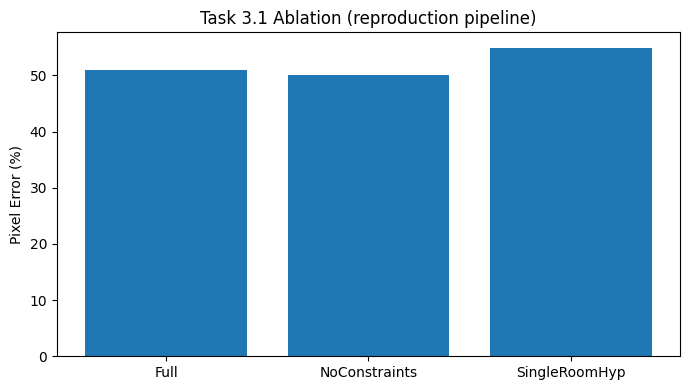

Saved results/task3_1_ablation_comparison.png


In [8]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def eval_mean_error(data):
    vals=[]
    for rgb, gt in data:
        gc_mask = infer_geometric_context(rgb, svm_model, scaler)
        room_h = generate_room_hypotheses(rgb)
        obj_h = generate_object_hypotheses(rgb)
        cfg = beam_search(rgb, gc_mask, room_h, obj_h, learned_w, learned_w_phi)
        if cfg is None:
            vals.append(1.0)
        else:
            vals.append(evaluate_loss(cfg, gt, rgb.shape))
    return float(np.mean(vals))*100.0

if test_data and svm_model is not None:
    subset=test_data[:30]

    # Full
    full_err=eval_mean_error(subset)

    # Ablation 1: disable compatibility filter
    _orig_filter = filter_compatible
    def filter_no_constraints(room, objects):
        return list(objects)
    globals()['filter_compatible']=filter_no_constraints
    abl1_err=eval_mean_error(subset)
    globals()['filter_compatible']=_orig_filter

    # Ablation 2: single room hypothesis
    _orig_rooms = generate_room_hypotheses
    def one_room_hyp(image, n_samples=10):
        return _orig_rooms(image, n_samples=1)
    globals()['generate_room_hypotheses']=one_room_hyp
    abl2_err=eval_mean_error(subset)
    globals()['generate_room_hypotheses']=_orig_rooms

    print(f'Full: {full_err:.2f}%')
    print(f'Abl1 no-constraints: {abl1_err:.2f}%')
    print(f'Abl2 single-room-hyp: {abl2_err:.2f}%')

    plt.figure(figsize=(7,4))
    labels=['Full','NoConstraints','SingleRoomHyp']
    vals=[full_err, abl1_err, abl2_err]
    plt.bar(labels, vals)
    plt.ylabel('Pixel Error (%)')
    plt.title('Task 3.1 Ablation (reproduction pipeline)')
    plt.tight_layout()
    out=RESULTS_DIR/'task3_1_ablation_comparison.png'
    plt.savefig(out, dpi=140, bbox_inches='tight')
    plt.show()
    print('Saved', out)
else:
    print('Data/model unavailable.')